# Implementasi Clustering untuk Menemukan Pola pada Data Nasabah Kartu Kredit
## Segmentasi Nasabah Kartu Kredit Menggunakan K-Means Clustering (Metodologi CRISP-DM)

**Sumber Dataset:** Kaggle [Credit Card Customer](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers) oleh Sakshi Goyal

Notebook ini menyusun seluruh proyek data science mengikuti tahapan **CRISP-DM**:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation 
6. Deployment


## 1. Business Understanding

### 1.1 Latar Belakang
Sebuah lembaga atau perusahaan penyedia kartu kredit memiliki data perilaku penggunaan kartu dari ribuan nasabah aktif. Selama ini, perusahaan belum memiliki pengelompokan nasabah yang jelas berdasarkan karakteristik dan kebiasaan transaksi mereka, sehingga menyulitkan manajemen dalam merumuskan strategi layanan atau promosi yang tepat sasaran.

### 1.2 Tujuan Bisnis
Menemukan segmen-segmen nasabah kartu kredit secara objektif berdasarkan pola perilaku penggunaan kartu, sehingga perusahaan dapat:
- Merancang kampanye pemasaran, program loyalitas, atau penawaran produk yang dipersonalisasi sesuai profil masing-masing segmen (misalnya penyesuaian limit atau reward transaksi).
- Mengidentifikasi kelompok nasabah dengan tingkat aktivitas tinggi (power users) maupun nasabah prioritas (high net worth).
- Memahami pola pemanfaatan kredit nasabah untuk mendukung pengambil keputusan dalam manajemen portofolio kartu kredit.

### 1.3 Tujuan Data Mining
Menerapkan algoritma clustering berbasis unsupervised learning, khususnya K-Means, untuk mengelompokkan nasabah ke dalam beberapa segmen optimal berdasarkan fitur-fitur numerik yang merepresentasikan profil demografi dan perilaku transaksi, yaitu:
- Customer_Age
- Credit_Limit
- Total_Revolving_Bal
- Total_Trans_Amt
- Total_Trans_Ct
- Avg_Utilization_Ratio

### 1.4 Kriteria Keberhasilan
- Diperoleh jumlah klaster optimal (K) yang didukung oleh analisis Elbow Method dan evaluasi Silhouette Score.
- Setiap klaster dapat diinterpretasikan secara jelas dari sudut pandang bisnis (memiliki karakteristik atau "persona" nasabah yang spesifik, seperti nasabah reguler, konservatif, high credit limit, dan power user).
- Model pengelompokan berhasil dilatih dan menghasilkan sebaran data yang stabil pada masing-masing klaster.

### 1.5 Kesesuaian Dataset untuk Masalah Clustering
Dataset ini sangat sesuai untuk pendekatan clustering karena:
- Seluruh fitur utama yang digunakan bersifat numerik kuantitatif, sehingga merepresentasikan perilaku dan batas finansial nasabah secara terukur.
- Bersifat unsupervised, di mana data tidak memiliki label atau target kategori sebelumnya, sehingga K-Means sangat ideal untuk menemukan pola alami di dalam data.
- Variasi nilai antar fitur (seperti rentang Customer_Age yang kecil dibandingkan Credit_Limit yang besar) ditangani melalui tahap standardisasi (scaling), sehingga memungkinkan pembentukan kelompok nasabah yang akurat dan objektif.


In [40]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_columns', None)

## 2. Data Understanding

Pada tahap ini kita akan memuat dataset, memeriksa struktur data, tipe data, nilai yang hilang (missing value), statistik deskriptif, serta melakukan eksplorasi visual awal (EDA) untuk memahami karakteristik penggunaan kartu kredit nasabah.


In [6]:
# Memuat dataset
df = pd.read_csv('BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [7]:
df.shape

(10127, 23)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [10]:
# Memeriksa nilai yang hilang (missing values)
print('Jumlah missing value per kolom:')
print(df.isnull().sum())
print('\nJumlah baris duplikat:', df.duplicated().sum())

Jumlah missing value per kolom:
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category 

In [13]:
# Fitur numerik yang akan dipakai
features = [
    'Customer_Age',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]

X = df[features].copy()

In [15]:
df[features].describe()

,Customer_Age,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,8631.953698,1162.814061,4404.086304,64.858695,0.274894
std,8.016814,9088.776650,814.987335,3397.129254,23.472570,0.275691
min,26.000000,1438.300000,0.000000,510.000000,10.000000,0.000000
25%,41.000000,2555.000000,359.000000,2155.500000,45.000000,0.023000
50%,46.000000,4549.000000,1276.000000,3899.000000,67.000000,0.176000
75%,52.000000,11067.500000,1784.000000,4741.000000,81.000000,0.503000
max,73.000000,34516.000000,2517.000000,18484.000000,139.000000,0.999000


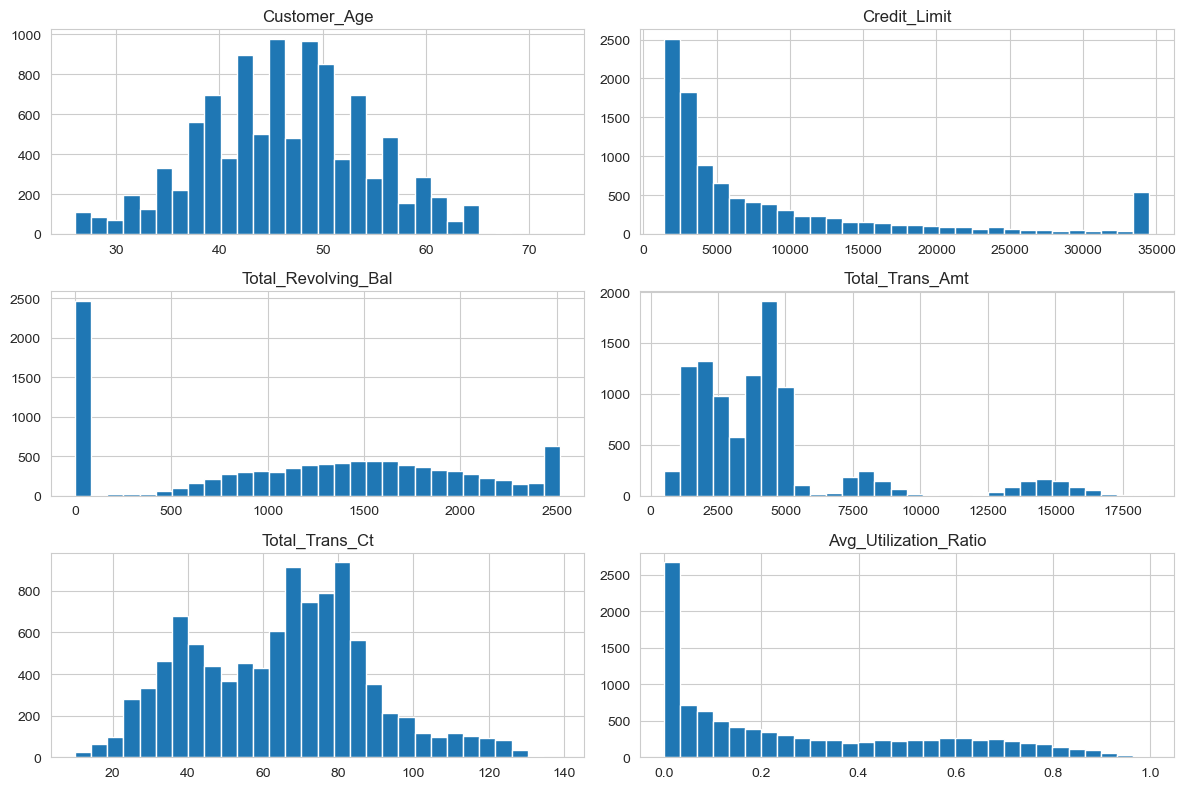

In [17]:
# Distribusi beberapa fitur numerik utama
df[features].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

**Insight dari Data Understanding:**
Dataset memiliki 10.127 data dan 23 kolom. Tidak terdapat missing value maupun data duplikat. Enam fitur numerik yang digunakan memiliki variasi nilai yang cukup beragam dan menggambarkan karakteristik serta aktivitas penggunaan kartu kredit nasabah.


## 3. Data Preparation

Tahap ini mencakup: penanganan pengecekan outlier, pemilihan fitur untuk clustering, dan standardisasi skala data. 

In [19]:
features = [
    'Customer_Age',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]

X = df[features].copy()

X.head()

,Customer_Age,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,45,12691.0,777,1144,42,0.061
1,49,8256.0,864,1291,33,0.105
2,51,3418.0,0,1887,20,0.000
3,40,3313.0,2517,1171,20,0.760
4,40,4716.0,0,816,28,0.000


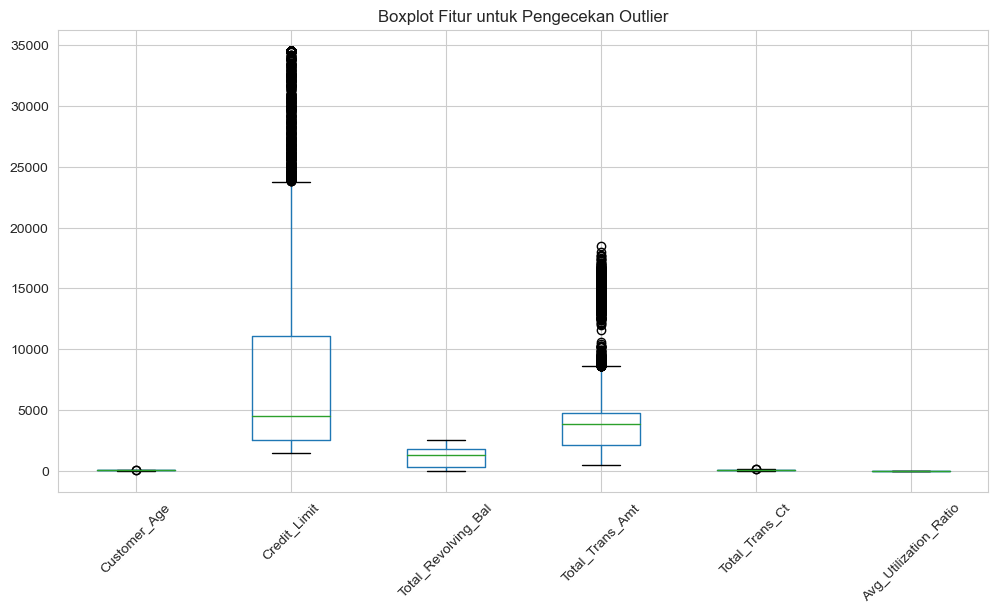

In [20]:
# Pengecekan outlier
X.boxplot(figsize=(12, 6))
plt.title('Boxplot Fitur untuk Pengecekan Outlier')
plt.xticks(rotation=45)
plt.show()

In [41]:
# Standardisasi skala fitur 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,Customer_Age,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,-0.165406,0.446622,-0.473422,-0.959707,-0.973895,-0.775882
1,0.333570,-0.041367,-0.366667,-0.916433,-1.357340,-0.616276
2,0.583058,-0.573698,-1.426858,-0.740982,-1.911206,-0.997155
3,-0.789126,-0.585251,1.661686,-0.951758,-1.911206,1.759686
4,-0.789126,-0.430877,-1.426858,-1.056263,-1.570365,-0.997155


## 4. Modeling

Kita menggunakan algoritma K-Means Clustering. Untuk menentukan jumlah cluster (k) yang optimal, digunakan dua pendekatan:
1. Elbow Method, melihat titik "siku" pada grafik WCSS (Within-Cluster Sum of Squares).
2. Silhouette Score, mengukur seberapa baik pemisahan antar cluster (semakin mendekati 1 semakin baik).


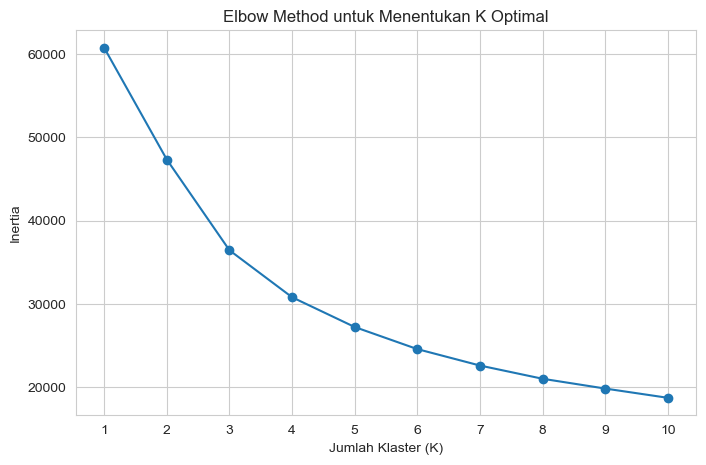

In [23]:
# Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

k = 2 -> Silhouette Score = 0.2225
k = 3 -> Silhouette Score = 0.2641
k = 4 -> Silhouette Score = 0.2822
k = 5 -> Silhouette Score = 0.2489
k = 6 -> Silhouette Score = 0.2533
k = 7 -> Silhouette Score = 0.2336
k = 8 -> Silhouette Score = 0.2365
k = 9 -> Silhouette Score = 0.2379
k = 10 -> Silhouette Score = 0.2307


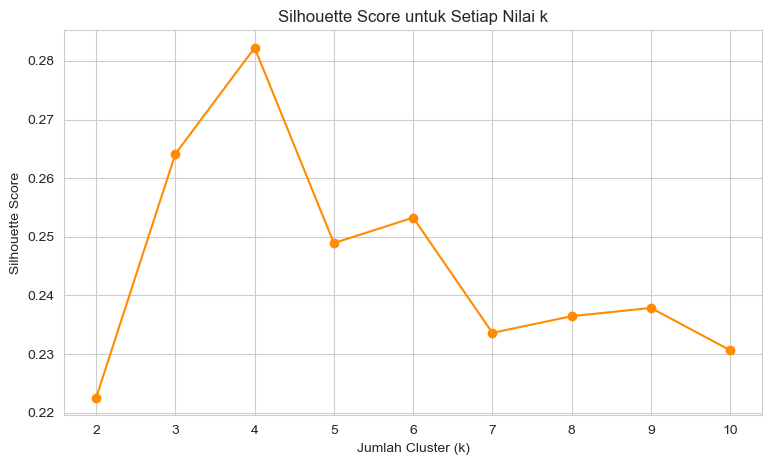

In [42]:
# Silhouette Score
from sklearn.metrics import silhouette_score

skor_siluet = []

K_range_silhouettes = range(2, 11)

for k in K_range_silhouettes:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    label_temp = kmeans_temp.fit_predict(X_scaled)
    skor = silhouette_score(X_scaled, label_temp)
    skor_siluet.append(skor)
    print(f'k = {k} -> Silhouette Score = {skor:.4f}')

# Visualisasi Silhouette Score untuk setiap nilai k
plt.figure(figsize=(9, 5))
plt.plot(list(K_range_silhouettes), skor_siluet, marker='o', color='darkorange', linestyle='-')
plt.title('Silhouette Score untuk Setiap Nilai k')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range_silhouettes))
plt.grid(True)
plt.show()

In [43]:
# 4.3 Melatih model K-Means final dengan k optimal
k_optimal = 4  

kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f'Model K-Means dengan k={k_optimal} berhasil dilatih.')
print(df['Cluster'].value_counts().sort_index())

Model K-Means dengan k=4 berhasil dilatih.
Cluster
0    4396
1    3149
2    1675
3     907
Name: count, dtype: int64


In [31]:
# Menghitung nilai rata-rata fitur berdasarkan klaster
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

         Customer_Age  Credit_Limit  Total_Revolving_Bal  Total_Trans_Amt  \
Cluster                                                                     
0           46.445177   3785.661215          1683.223385      3567.497498   
1           46.323277   5739.598095           277.535726      3398.226739   
2           46.568955  23918.749254          1337.128955      3521.429254   
3           45.308710  13931.785006          1392.190739     13581.094818   

         Total_Trans_Ct  Avg_Utilization_Ratio  
Cluster                                         
0             62.712011               0.533757  
1             58.777072               0.052723  
2             58.669254               0.067414  
3            107.808159               0.174759  


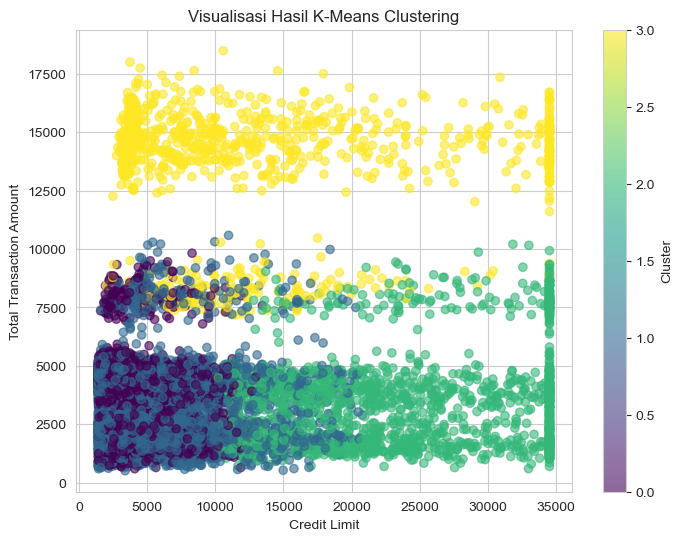

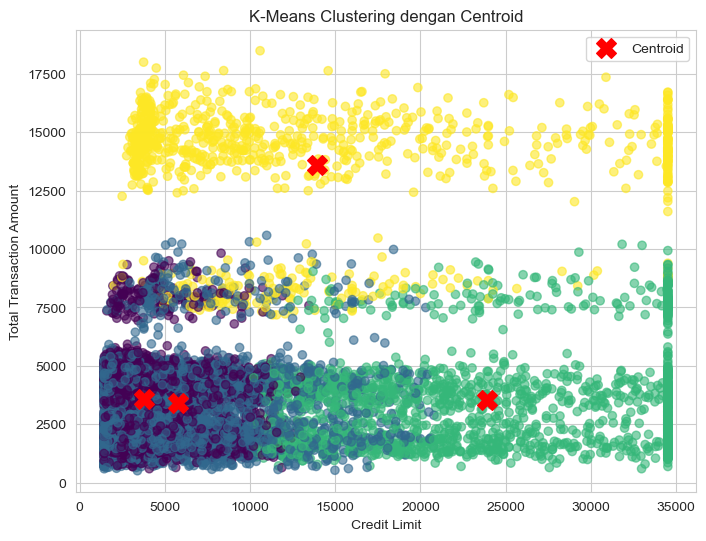

In [32]:
# 1. Visualisasi Scatter Plot Klaster
plt.figure(figsize=(8, 6))
plt.scatter(df['Credit_Limit'], df['Total_Trans_Amt'], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Credit Limit')
plt.ylabel('Total Transaction Amount')
plt.title('Visualisasi Hasil K-Means Clustering')
plt.colorbar(label='Cluster')
plt.show()


# 2. Visualisasi dengan Centroid (Titik Pusat)
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(df['Credit_Limit'], df['Total_Trans_Amt'], c=df['Cluster'], cmap='viridis', alpha=0.6)

# Menandai titik centroid dengan tanda silang merah ('X')
plt.scatter(
    centers[:, features.index('Credit_Limit')], 
    centers[:, features.index('Total_Trans_Amt')], 
    c='red', 
    marker='X', 
    s=200, 
    label='Centroid'
)

plt.xlabel('Credit Limit')
plt.ylabel('Total Transaction Amount')
plt.title('K-Means Clustering dengan Centroid')
plt.legend()
plt.show()

## 5. Evaluation

Pada tahap ini kita mengevaluasi kualitas cluster secara kuantitatif (Silhouette Score final) dan menginterpretasikan karakteristik tiap cluster secara bisnis, agar hasil clustering masuk akal dan dapat ditindaklanjuti sesuai tujuan bisnis di tahap awal.


In [46]:
# Evaluasi kuantitatif — Silhouette Score model final
skor_final = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhouette Score model final (k={k_optimal}): {skor_final:.4f}')

print('\nPerbandingan dengan skor tiap k (dari sel Silhouette Method di atas):')
for k, skor in zip(K_range_silhouettes, skor_siluet):
    tanda = '  <- dipilih' if k == k_optimal else ''
    print(f'  k = {k} -> {skor:.4f}{tanda}')

Silhouette Score model final (k=4): 0.2822

Perbandingan dengan skor tiap k (dari sel Silhouette Method di atas):
  k = 2 -> 0.2225
  k = 3 -> 0.2641
  k = 4 -> 0.2822  <- dipilih
  k = 5 -> 0.2489
  k = 6 -> 0.2533
  k = 7 -> 0.2336
  k = 8 -> 0.2365
  k = 9 -> 0.2379
  k = 10 -> 0.2307


In [47]:
# Profil rata-rata tiap cluster (menggunakan model final k=4)
profil_cluster = df.groupby('Cluster')[features].mean().round(2)
profil_cluster['Jumlah_Nasabah'] = df['Cluster'].value_counts().sort_index()
profil_cluster

,Customer_Age,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Jumlah_Nasabah
Cluster,,,,,,,
0,46.45,3785.66,1683.22,3567.50,62.71,0.53,4396
1,46.32,5739.60,277.54,3398.23,58.78,0.05,3149
2,46.57,23918.75,1337.13,3521.43,58.67,0.07,1675
3,45.31,13931.79,1392.19,13581.09,107.81,0.17,907


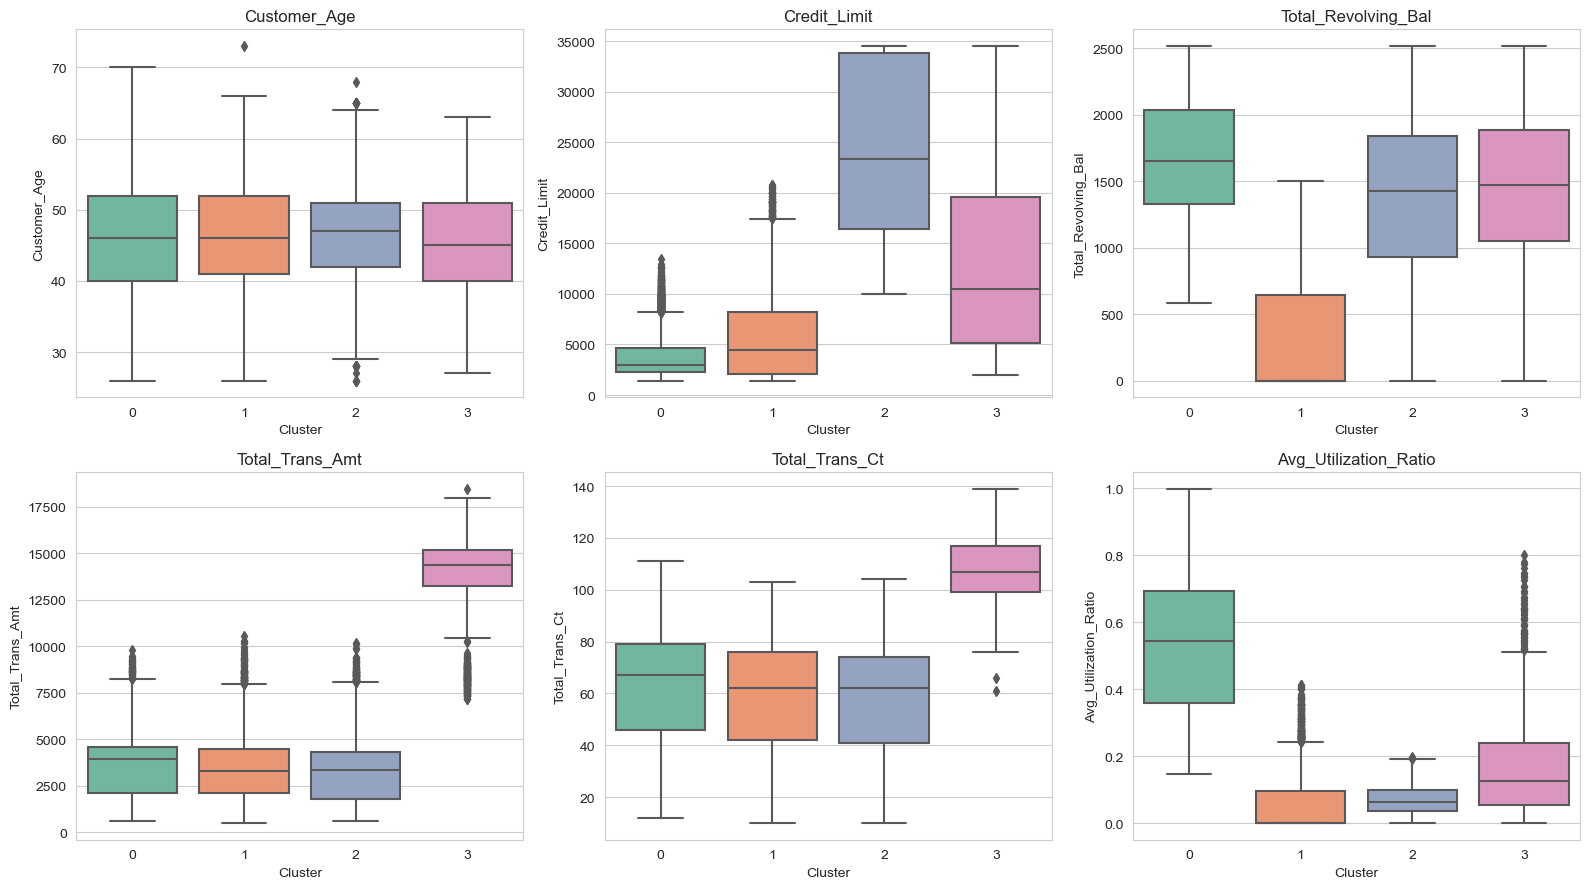

In [48]:
# Visualisasi perbandingan karakteristik antar cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Cluster', y=col, ax=ax, palette='Set2')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Interpretasi Bisnis Setiap Cluster

Berdasarkan profil rata-rata (k=4, Silhouette Score ≈ 0.28), berikut adalah 4 persona nasabah beserta karakteristik dan strateginya:

Cluster 0: Revolver Berisiko (4.396 nasabah)
Kelompok ini memiliki limit terendah (3.786) namun tingkat penggunaannya paling tinggi mencapai 53%, dengan saldo tertunggak terbesar (1.683).
Strategi: Pantau risiko kredit dengan ketat, tawarkan program restrukturisasi atau cicilan, dan berikan edukasi keuangan.

Cluster 1: Nasabah Sehat / Transactors (3.149 nasabah)
Kelompok yang rutin melunasi tagihan. Mereka memiliki tingkat utilitas paling rendah (5%) dan hampir tidak ada saldo tertunggak (278).
Strategi: Jaga loyalitas mereka dengan reward reguler dan lakukan cross-selling untuk produk simpanan atau investasi.

Cluster 2: Nasabah Premium / Elite (1.675 nasabah)
Nasabah dengan limit kartu tertinggi (23.919) tetapi rasio penggunaannya masih tergolong rendah (7%) dengan nilai transaksi yang standar.
Strategi: Tawarkan layanan prioritas, upgrade ke kartu eksklusif, dan dorong transaksi melalui penawaran khusus bernilai tinggi.

Cluster 3: Power User / Heavy Spender (907 nasabah)
Kelompok dengan performa transaksi terbaik, mencatat nilai transaksi tertinggi (13.581) dan frekuensi penggunaan paling sering (107.8 kali).
Strategi: Prioritaskan retensi kelompok ini. Berikan cashback atau poin reward ekstra yang sepadan dengan besarnya pengeluaran mereka.

## 6. Deployment

Model K-Means final beserta `StandardScaler` disimpan dalam format `joblib`, agar dapat dimuat kembali oleh aplikasi **Streamlit** (`app.py`) untuk memprediksi segmen nasabah baru secara interaktif.

File-file yang digunakan untuk deployment:
- `app.py` — source code aplikasi Streamlit
- `kmeans_model.joblib` — model K-Means terlatih
- `scaler.joblib` — StandardScaler terlatih (untuk menyamakan skala input baru)
- `requirements.txt` — daftar pustaka yang dibutuhkan untuk menjalankan aplikasi


In [49]:
# Menyimpan model dan scaler untuk digunakan pada aplikasi deployment (Streamlit)
joblib.dump(kmeans_final, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Model dan scaler berhasil disimpan: kmeans_model.pkl, scaler.pkl')

Model dan scaler berhasil disimpan: kmeans_model.pkl, scaler.pkl


### Cara Menjalankan Aplikasi Secara Lokal
```bash
pip install -r requirements.txt
streamlit run app.py
```